In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

#%matplotlib inline
#sns.set_style("whitegrid")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

DIR = "/content/drive/MyDrive/Analítica de datos - UF3 /Act Complementarias/XGBoost"
os.chdir(DIR)

In [6]:

df = pd.read_csv("Wholesale-customers-data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [7]:
print("\nStatistical Summary")
display(df.describe())



Statistical Summary


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [8]:
X = df.drop('Channel', axis=1)

# Convert Channel into binary labels
y = df['Channel'].map({1:1, 2:0})

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [15]:
params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}
'''
params = {
    # Objetivo
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',

    # Complejidad del árbol
    'max_depth': 4,
    'min_child_weight': 1,
    'gamma': 0,  # mínimo gain para hacer split

    # Regularización
    'alpha': 10,      # L1
    'lambda': 1,      # L2

    # Boosting
    'learning_rate': 0.1,
    'n_estimators': 200,

    # Submuestreo (muy importante para evitar overfitting)
    'subsample': 0.8,
    'colsample_bytree': 0.8,

    # Otros útiles
    'scale_pos_weight': 1,  # útil si hay desbalance
    'random_state': 42,
    'n_jobs': -1
}
'''
model = XGBClassifier(**params)

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [18]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

model = XGBClassifier()

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross validation
    scoring='accuracy',   # o 'roc_auc'
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Mejor score: 0.9351136964569011


In [19]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [ ]:
best_params = grid.best_params_

model_final = XGBClassifier(**best_params)

model_final.fit(X_train, y_train)

y_pred = model_final.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.9166666666666666

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        38
           1       0.97      0.91      0.94        94

    accuracy                           0.92       132
   macro avg       0.89      0.92      0.90       132
weighted avg       0.92      0.92      0.92       132



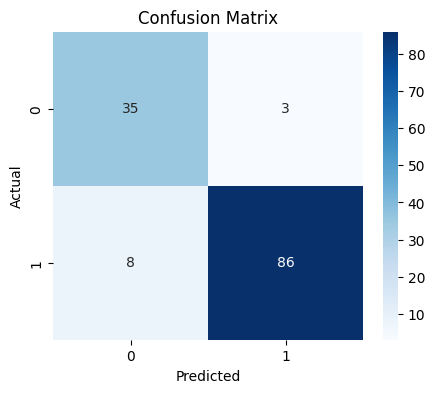

In [21]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 800x600 with 0 Axes>

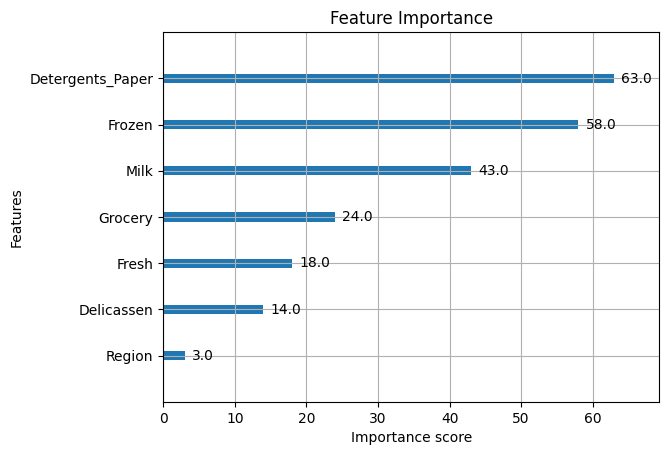

In [12]:
plt.figure(figsize=(8,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

<Figure size 2000x1000 with 0 Axes>

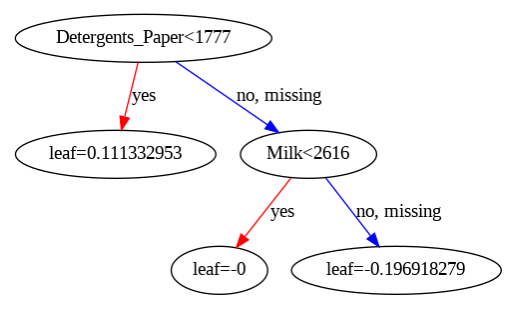

In [14]:
plt.figure(figsize=(20,10))
xgb.plot_tree(model)
plt.show()

In [ ]:
def evaluate_classification_model(model, X_test, y_test):
    """
    Evalúa un modelo de clasificación mostrando métricas clave y visualizaciones.

    Esta función realiza:
    - Predicciones sobre el conjunto de prueba
    - Cálculo de accuracy
    - Generación del classification report (precision, recall, f1-score)
    - Visualización de la matriz de confusión
    - Visualización de la importancia de variables (feature importance)

    Parameters
    ----------
    model : object
        Modelo de clasificación previamente entrenado (por ejemplo, XGBClassifier).
        Debe tener los métodos `.predict()` y ser compatible con `xgboost.plot_importance`.

    X_test : array-like or pandas DataFrame
        Conjunto de datos de prueba (features).

    y_test : array-like or pandas Series
        Etiquetas reales del conjunto de prueba.

    Returns
    -------
    dict
        Diccionario con métricas clave:
        - 'accuracy': precisión del modelo
        - 'classification_report': reporte completo en formato string

    Notes
    -----
    - Requiere las siguientes librerías:
        sklearn.metrics, matplotlib.pyplot, seaborn, xgboost
    - La función muestra gráficos directamente (no los retorna).
    """

    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    import xgboost as xgb

    # Predicciones
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("Model Accuracy:", accuracy)

    # Classification Report
    print("\nClassification Report")
    report = classification_report(y_test, y_pred)
    print(report)

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Feature Importance
    plt.figure(figsize=(8, 6))
    xgb.plot_importance(model)
    plt.title("Feature Importance")
    plt.show()

    return {
        "accuracy": accuracy,
        "classification_report": report
    }